In [20]:
import matplotlib
import matplotlib.pyplot as plt
import os
import pandas as pd
import glob
import numpy as np
import csv
from matplotlib.lines import Line2D


In [21]:
colors_dict={'50x10': (128/255.,128/255.,128/255.), 
             '50x12P5': (51/255.,187/255.,238/255.),
             '50x15': (204/255.,102/255.,119/255.),
             '50x20': (153/255.,153/255.,51/255.),
             '50x25': (17/255.,119/255.,51/255.),
             '100x25': (136/255.,34/255.,85/255.),
             '100x25x150': (51/255.,34/255.,136/255.)
            }
markers_dict = {
    '50x10': ['-', 'v', 40], 
    '50x12P5': ['-', '^', 30],
    '50x15': ['-', '<', 40],
    '50x20': ['-', '>', 40],
    '50x25': ['-', '*', 40],
    '100x25': ['--', 'o', 40],
    '100x25x150': [':', 'o', 40]
}

colors_dict_old={'50x10': 'tab:brown', 
             '50x12P5': 'tab:red',
             '50x15': 'tab:green',
             '50x20': 'tab:orange',
             '50x25': 'tab:purple',
             '100x25': 'tab:olive',
             '100x25x150': 'tab:blue'
            }


## Sensor geometry study - barrel region @ 0.2 GeV with 0e Noise Threshold

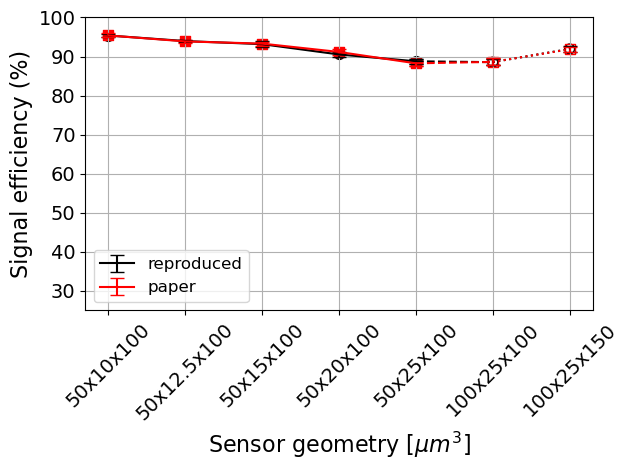

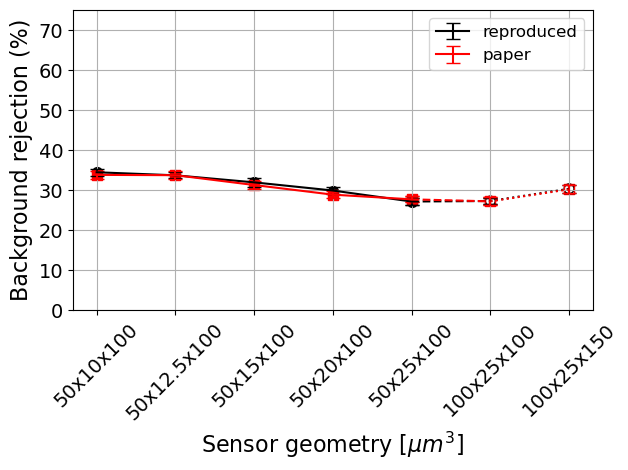

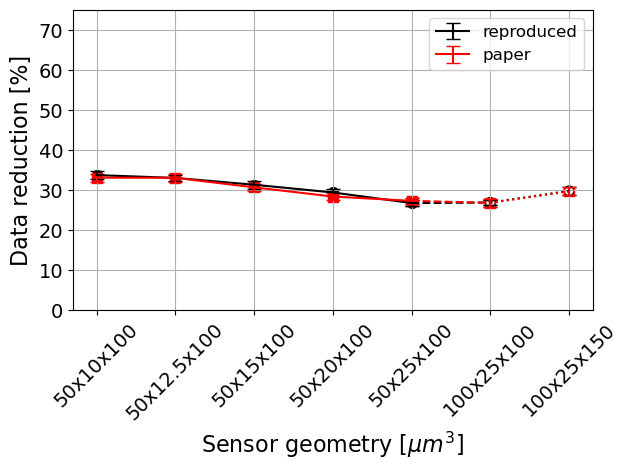

In [27]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

results_dir = 'results0_1'

legend_dict = {
    '50x10': '50x10x100',
    '50x12P5': '50x12.5x100',
    '50x15': '50x15x100',
    '50x20': '50x20x100',
    '50x25': '50x25x100',
    '100x25': '100x25x100',
    '100x25x150': '100x25x150'
}

save_dir = './paper_plots/'
os.makedirs(save_dir, exist_ok=True)

sizes = ['50x10', '50x12P5', '50x15', '50x20', '50x25', '100x25', '100x25x150']
full_sizes = ['50x10x100', '50x12.5x100', '50x15x100', '50x20x100', '50x25x100', '100x25x100', '100x25x150']
thresholds = [0.1, 0.15, 0.2, 0.3, 0.4, 0.5]

df_temp = pd.read_csv(
    './' + results_dir + '/final_results.txt',
    names=["sensor_geom","threshold","run_iter","sig_eff","sig_eff_err","bg_rej","bg_rej_err","dat_red","dat_red_err"]
)

df_temp_paper = pd.read_csv(
    './' + results_dir + '/final_results_paper.txt',
    names=["sensor_geom","threshold","run_iter","sig_eff","sig_eff_err","bg_rej","bg_rej_err","dat_red","dat_red_err"]
)

def build_dictionary(df, sizes, thresholds):
    dictionary = {size: [] for size in sizes}

    for size_iter in sizes:
        for threshold in thresholds:
            subset = df[(df.sensor_geom == size_iter) & (df.threshold == threshold)]
            if subset.empty:
                continue

            sig_eff_errStat = subset["sig_eff_err"].max()
            sig_eff_errML = subset["sig_eff"].std()
            sig_eff_errML = 0 if np.isnan(sig_eff_errML) else sig_eff_errML
            sig_eff_err = np.sqrt(sig_eff_errML**2 + sig_eff_errStat**2)
            sig_eff = subset["sig_eff"].mean()

            bg_rej_errStat = subset["bg_rej_err"].max()
            bg_rej_errML = subset["bg_rej"].std()
            bg_rej_errML = 0 if np.isnan(bg_rej_errML) else bg_rej_errML
            bg_rej_err = np.sqrt(bg_rej_errML**2 + bg_rej_errStat**2)
            bg_rej = subset["bg_rej"].mean()

            dat_red_errStat = subset["dat_red_err"].max()
            dat_red_errML = subset["dat_red"].std()
            dat_red_errML = 0 if np.isnan(dat_red_errML) else dat_red_errML
            dat_red_err = np.sqrt(dat_red_errML**2 + dat_red_errStat**2)
            dat_red = subset["dat_red"].mean()

            dictionary[size_iter].append([
                threshold, sig_eff, sig_eff_err,
                bg_rej, bg_rej_err,
                dat_red, dat_red_err
            ])

    return dictionary

dict_temp = build_dictionary(df_temp, sizes, thresholds)
dict_paper = build_dictionary(df_temp_paper, sizes, thresholds)

def extract_metric(dictionary, threshold, metric_idx, err_idx):
    vals = []
    errs = []
    for size_iter in sizes:
        found = False
        for values in dictionary[size_iter]:
            if values[0] == threshold:
                vals.append(100 * values[metric_idx])
                errs.append(100 * values[err_idx])
                found = True
                break
        if not found:
            vals.append(np.nan)
            errs.append(np.nan)
    return vals, errs

def plot_series(xlabels, y, yerr, label, color, marker, linestyle_main='-', linestyle_mid='--', linestyle_last=':'):
    # main solid segment
    plt.errorbar(xlabels[:-2], y[:-2], yerr=yerr[:-2], capsize=5, fmt=linestyle_main,
                 color=color, label=label)
    # middle dashed segment
    plt.errorbar(xlabels[-3:-1], y[-3:-1], yerr=yerr[-3:-1], capsize=5, fmt=linestyle_mid,
                 color=color)
    # last dotted segment
    plt.errorbar(xlabels[-2:], y[-2:], yerr=yerr[-2:], capsize=5, fmt=linestyle_last,
                 color=color)

    for i in range(len(xlabels)):
        face = 'none' if '100x25' in sizes[i] else color
        plt.scatter(xlabels[i], y[i], marker=marker, facecolors=face, color=color, s=50)

threshold_to_plot = 0.2

# --------------------------
# Signal Efficiency
# --------------------------
plt.figure()

se_temp, se_err_temp = extract_metric(dict_temp, threshold_to_plot, 1, 2)
se_paper, se_err_paper = extract_metric(dict_paper, threshold_to_plot, 1, 2)

plot_series(full_sizes, se_temp, se_err_temp, label='reproduced', color='k', marker='o')
plot_series(full_sizes, se_paper, se_err_paper, label='paper', color='r', marker='s')
plt.grid(True)
plt.xlabel('Sensor geometry [$\\mu m^3$]', fontsize=16)
plt.ylabel('Signal efficiency (%)', fontsize=16)
plt.ylim(25, 100)
plt.yticks(fontsize=14)
plt.xticks(rotation=45, fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig(f'{save_dir}/final-signal-efficiency-vs-geometry.png', dpi=300)
plt.show()

# --------------------------
# Background Rejection
# --------------------------
plt.figure()

bgr_temp, bgr_err_temp = extract_metric(dict_temp, threshold_to_plot, 3, 4)
bgr_paper, bgr_err_paper = extract_metric(dict_paper, threshold_to_plot, 3, 4)

plot_series(full_sizes, bgr_temp, bgr_err_temp, label='reproduced', color='k', marker='o')
plot_series(full_sizes, bgr_paper, bgr_err_paper, label='paper', color='r', marker='s')
plt.grid(True)
plt.xlabel('Sensor geometry [$\\mu m^3$]', fontsize=16)
plt.ylabel('Background rejection (%)', fontsize=16)
plt.ylim(0, 75)
plt.yticks(fontsize=14)
plt.xticks(rotation=45, fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig(f'{save_dir}/final-background-rejection-vs-geometry.png', dpi=300)
plt.show

# --------------------------
# Data Reduction
# --------------------------
plt.figure()

dr_temp, dr_err_temp = extract_metric(dict_temp, threshold_to_plot, 5, 6)
dr_paper, dr_err_paper = extract_metric(dict_paper, threshold_to_plot, 5, 6)

plot_series(full_sizes, dr_temp, dr_err_temp, label='reproduced', color='k', marker='o')
plot_series(full_sizes, dr_paper, dr_err_paper, label='paper', color='r', marker='s')
plt.grid(True)
plt.xlabel('Sensor geometry [$\\mu m^3$]', fontsize=16)
plt.ylabel("Data reduction [%]", fontsize=16)
plt.ylim(0, 75)
plt.yticks(fontsize=14)
plt.xticks(rotation=45, fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig(f'{save_dir}/final-data-reduction-vs-geometry.png', dpi=300)
plt.show()

## Noise Threshold Study @ 0.2 GeV

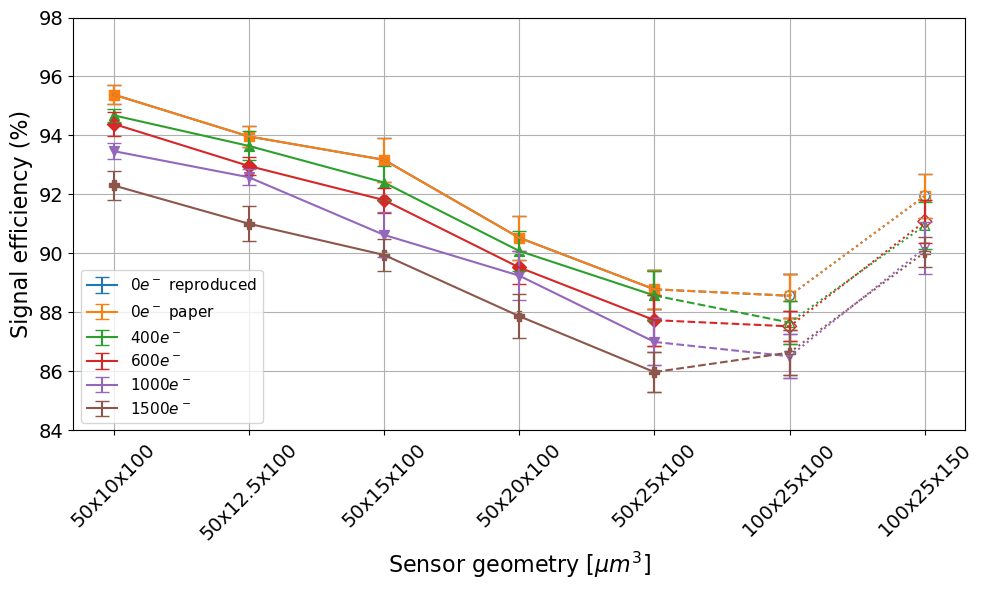

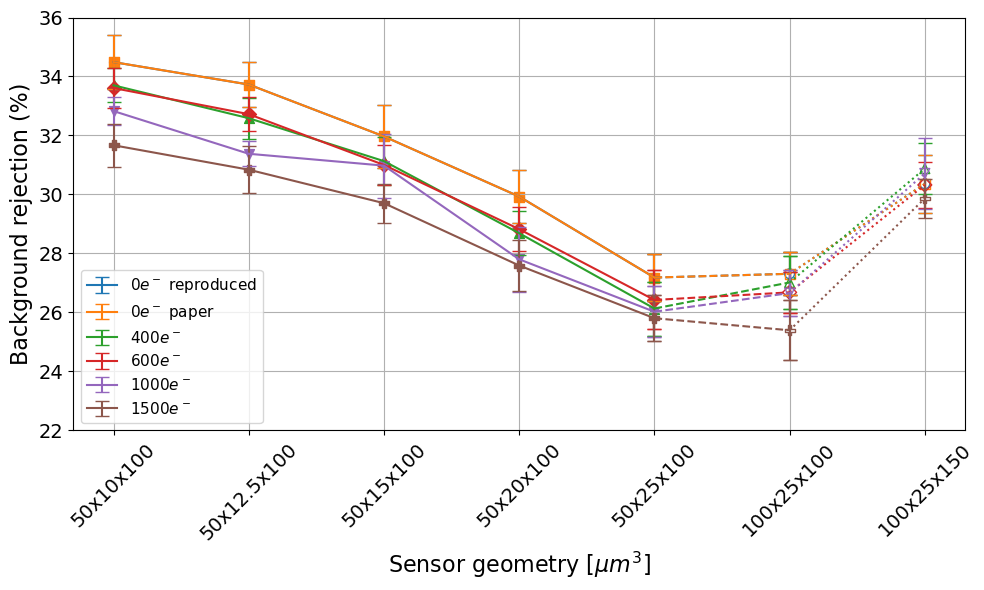

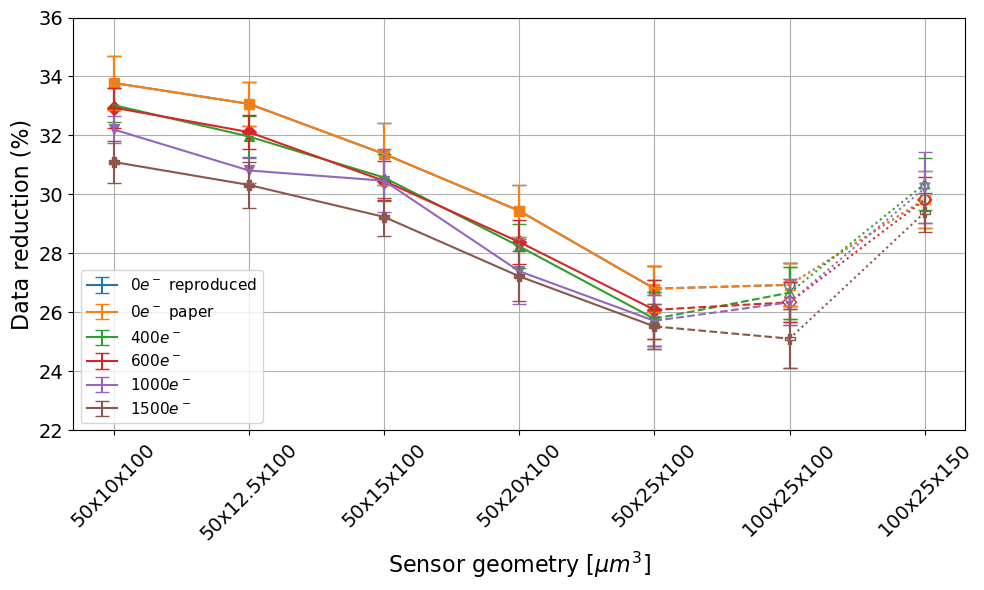

In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

save_dir = './paper_plots/'
os.makedirs(save_dir, exist_ok=True)

sizes = ['50x10', '50x12P5', '50x15', '50x20', '50x25', '100x25', '100x25x150']
full_sizes = ['50x10x100', '50x12.5x100', '50x15x100', '50x20x100', '50x25x100', '100x25x100', '100x25x150']
thresholds = [0.1, 0.15, 0.2, 0.3, 0.4, 0.5]


results_dirs = {
    '0$e^-$ reproduced': 'results0_1',
    '0$e^-$ paper': 'results0_1',
    '400$e^-$': 'results400_1',
    '600$e^-$': 'results600_1',
    '1000$e^-$': 'results1000_1',
    '1500$e^-$': 'results1500_1'
}

def read_results(filepath):
    return pd.read_csv(
        filepath,
        names=[
            "sensor_geom", "threshold", "run_iter",
            "sig_eff", "sig_eff_err",
            "bg_rej", "bg_rej_err",
            "dat_red", "dat_red_err"
        ]
    )

def build_dictionary(df, sizes, thresholds):
    dictionary = {size: [] for size in sizes}

    for size_iter in sizes:
        for threshold in thresholds:
            subset = df[(df.sensor_geom == size_iter) & (df.threshold == threshold)]
            if subset.empty:
                continue

            sig_eff_errStat = subset["sig_eff_err"].max()
            sig_eff_errML = subset["sig_eff"].std()
            sig_eff_errML = 0 if np.isnan(sig_eff_errML) else sig_eff_errML
            sig_eff_err = np.sqrt(sig_eff_errML**2 + sig_eff_errStat**2)
            sig_eff = subset["sig_eff"].mean()

            bg_rej_errStat = subset["bg_rej_err"].max()
            bg_rej_errML = subset["bg_rej"].std()
            bg_rej_errML = 0 if np.isnan(bg_rej_errML) else bg_rej_errML
            bg_rej_err = np.sqrt(bg_rej_errML**2 + bg_rej_errStat**2)
            bg_rej = subset["bg_rej"].mean()

            dat_red_errStat = subset["dat_red_err"].max()
            dat_red_errML = subset["dat_red"].std()
            dat_red_errML = 0 if np.isnan(dat_red_errML) else dat_red_errML
            dat_red_err = np.sqrt(dat_red_errML**2 + dat_red_errStat**2)
            dat_red = subset["dat_red"].mean()

            dictionary[size_iter].append([
                threshold, sig_eff, sig_eff_err,
                bg_rej, bg_rej_err,
                dat_red, dat_red_err
            ])

    return dictionary

def extract_metric(dictionary, threshold, metric_idx, err_idx):
    vals = []
    errs = []
    for size_iter in sizes:
        found = False
        for values in dictionary[size_iter]:
            if values[0] == threshold:
                vals.append(100 * values[metric_idx])
                errs.append(100 * values[err_idx])
                found = True
                break
        if not found:
            vals.append(np.nan)
            errs.append(np.nan)
    return vals, errs

def plot_series(xlabels, y, yerr, label, marker,
                linestyle_main='-', linestyle_mid='--', linestyle_last=':'):


    color = plt.gca()._get_lines.get_next_color()


    plt.errorbar(
        xlabels[:-2], y[:-2], yerr=yerr[:-2],
        capsize=5, fmt=linestyle_main,
        label=label,
        color=color
    )


    plt.errorbar(
        xlabels[-3:-1], y[-3:-1], yerr=yerr[-3:-1],
        capsize=5, fmt=linestyle_mid,
        color=color
    )


    plt.errorbar(
        xlabels[-2:], y[-2:], yerr=yerr[-2:],
        capsize=5, fmt=linestyle_last,
        color=color
    )


    for i in range(len(xlabels)):
        face = 'none' if '100x25' in sizes[i] else None
        plt.scatter(
            xlabels[i], y[i],
            marker=marker,
            facecolors=face,
            s=50,
            color=color
        )

all_dicts = {}

for label, folder in results_dirs.items():
    if label == '0eV paper':
        filepath = os.path.join(folder, 'final_results_paper.txt')
    else:
        filepath = os.path.join(folder, 'final_results.txt')

    df = read_results(filepath)
    all_dicts[label] = build_dictionary(df, sizes, thresholds)

threshold_to_plot = 0.2

plot_order = [
    ('0$e^-$ reproduced', 'o'),
    ('0$e^-$ paper', 's'),
    ('400$e^-$', '^'),
    ('600$e^-$', 'D'),
    ('1000$e^-$', 'v'),
    ('1500$e^-$', 'P')
]

# --------------------------
# Signal Efficiency
# --------------------------
plt.figure(figsize=(10, 6))

for label, marker in plot_order:
    se_vals, se_errs = extract_metric(all_dicts[label], threshold_to_plot, 1, 2)
    plot_series(full_sizes, se_vals, se_errs, label=label, marker=marker)

plt.xlabel('Sensor geometry [$\\mu m^3$]', fontsize=16)
plt.ylabel('Signal efficiency (%)', fontsize=16)
plt.ylim(84, 98)
plt.grid(True)
plt.yticks(fontsize=14)
plt.xticks(rotation=45, fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{save_dir}/final-signal-efficiency-vs-geometry-all-noises-zoom.png', dpi=300)
plt.show()

# --------------------------
# Background Rejection
# --------------------------
plt.figure(figsize=(10, 6))

for label, marker in plot_order:
    bgr_vals, bgr_errs = extract_metric(all_dicts[label], threshold_to_plot, 3, 4)
    plot_series(full_sizes, bgr_vals, bgr_errs, label=label, marker=marker)

plt.xlabel('Sensor geometry [$\\mu m^3$]', fontsize=16)
plt.ylabel('Background rejection (%)', fontsize=16)
plt.ylim(22, 36)
plt.grid(True)
plt.yticks(fontsize=14)
plt.xticks(rotation=45, fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{save_dir}/final-background-rejection-vs-geometry-all-noises-zoom.png', dpi=300)
plt.show()

# --------------------------
# Data Reduction
# --------------------------
plt.figure(figsize=(10, 6))

for label, marker in plot_order:
    dr_vals, dr_errs = extract_metric(all_dicts[label], threshold_to_plot, 5, 6)
    plot_series(full_sizes, dr_vals, dr_errs, label=label, marker=marker)

plt.xlabel('Sensor geometry [$\\mu m^3$]', fontsize=16)
plt.ylabel('Data reduction (%)', fontsize=16)
plt.ylim(22, 36)
plt.grid(True)
plt.yticks(fontsize=14)
plt.xticks(rotation=45, fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{save_dir}/final-data-reduction-vs-geometry-all-noises-zoom.png', dpi=300)
plt.show()